In [32]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [33]:
def create_env(slippery : bool = False):
  env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=slippery)
  return env

In [34]:
def custom_reward(env: gym.Env, step_penalty: float = 0.0, hole_penalty: float = 0.0, goal_reward: float = 1.0):
    desc = np.asarray(env.unwrapped.desc, dtype=str).flatten()  # shape: (n_states,)
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    # Build R[s, a, s'] based on the *destination* tile type
    reward = np.zeros((n_states, n_actions, n_states), dtype=float)
    for s in range(n_states):
        for a in range(n_actions):
            for _, s_next, _, _ in env.unwrapped.P[s][a]:
                tile = desc[s_next]
                if tile == "G":
                    reward[s, a, s_next] = goal_reward
                elif tile == "H":
                    reward[s, a, s_next] = hole_penalty
                else:
                    reward[s, a, s_next] = step_penalty  # S or F tiles

    # Recompute transition matrix cleanly
    transition = np.zeros((n_states, n_actions, n_states), dtype=float)
    for s in range(n_states):
        for a in range(n_actions):
            for prob, s_next, _, _ in env.unwrapped.P[s][a]:
                transition[s, a, s_next] += prob

    expected_reward = np.sum(transition * reward, axis=2)
    return transition, reward, expected_reward

In [35]:
def get_q_val(transition, reward, values, gamma):
  return reward + gamma * np.einsum("ijk,k->ij", transition, values)

In [36]:
def policy_eval(transition, reward, policy, gamma):
  n_states = transition.shape[0]
  row = np.arange(n_states)
  trans = transition[row, policy] #Transition Probabilities
  rew = reward[row, policy] #Reward
  return np.linalg.solve(np.eye(n_states) - gamma * trans, rew)

In [37]:
def policy_iteration(transition, reward, gamma=0.99, max_iterations=1000):
	n_states = transition.shape[0]
	policy = np.zeros(n_states, dtype=int)

	for iteration in range(max_iterations):
		values = policy_eval(transition, reward, policy, gamma)
		q = get_q_val(transition, reward, values, gamma)
		new_policy = np.argmax(q, axis=1)
		if np.array_equal(new_policy, policy):
			return values, policy, iteration + 1
		policy = new_policy

	values = policy_eval(transition, reward, policy, gamma)
	return values, policy, max_iterations

In [38]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

[1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 0 1 2 1 1 2 2 2 2 1 0 1 1 2 2 3 0 1
 1 2 1 1 0 0 2 2 1 0 1 1 0 2 3 0 1 0 1 2 2 3 0 2 2 2 0]


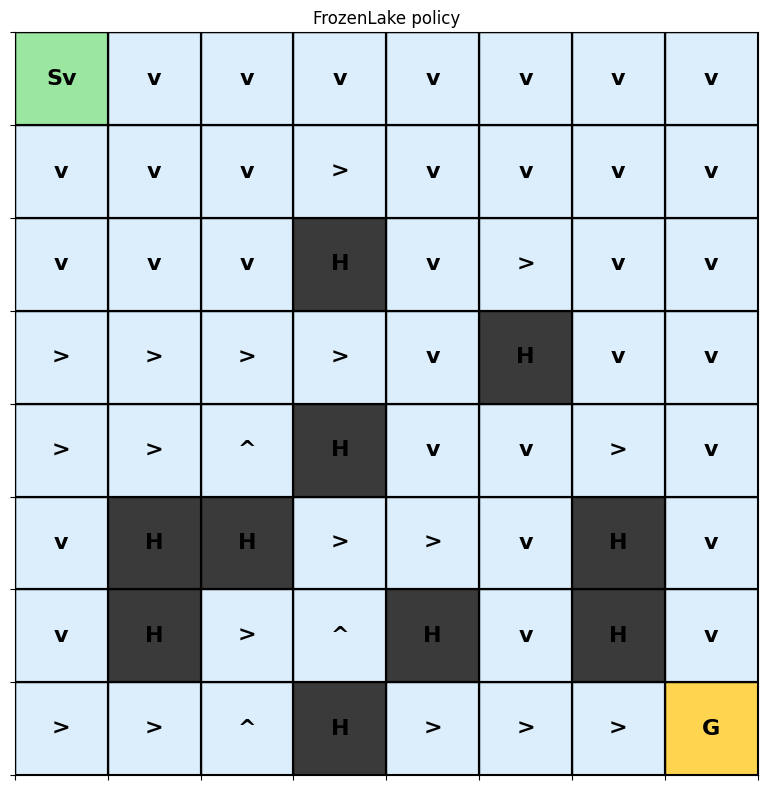

In [39]:
def main():
  env = create_env(slippery = False)
  transition, reward, expected_reward = custom_reward(env)
  gamma = 0.99
  _, policy, _ = policy_iteration(transition, expected_reward, gamma)
  print(policy)

  plot_policy_on_frozen_lake(env, policy)

if __name__ == "__main__":
  main()